In [1]:
# imports
import json
import pandas as pd
from src.config import PATH_FIG, PATH_CSV_RESULTS
from src.analysis.utils import plot_single_horizontal_bar_chart, plot_multi_horizontal_bar_chart
from src.analysis.moralchoice_analysis import disaggregate_moralchoice_results
from src.analysis.normbank_analysis import disaggregate_normbank_results
from src.analysis.reddit_analysis import disaggregate_reddit_verdict_results

In [2]:
dataset_configs = {
    'moralchoice_high_ambiguity': {
        'fn': disaggregate_moralchoice_results,
        'results': [
            "main/moralchoice_high_ambiguity/google_gemma-3-4b-it_moralchoice_high_ambiguity.csv",
            "main/moralchoice_high_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_high_ambiguity.csv",
            "main/moralchoice_high_ambiguity/Qwen_Qwen3-4B_moralchoice_high_ambiguity.csv",
            "main/moralchoice_high_ambiguity/openai_gpt-4.1_moralchoice_high_ambiguity.csv"
        ],
        'args': ("moralchoice_high_ambiguity.csv",)
    },
    'moralchoice_low_ambiguity': {
        'fn': disaggregate_moralchoice_results,
        'results': [
            "main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
            "main/moralchoice_low_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
            "main/moralchoice_low_ambiguity/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
            "main/moralchoice_low_ambiguity/openai_gpt-4.1_moralchoice_low_ambiguity.csv"
        ],
        'args': ("moralchoice_low_ambiguity.csv",)
    },
    'normbank': {
        'fn': disaggregate_normbank_results,
        'results': [
            "main/normbank/google_gemma-3-4b-it_normbank.csv",
            "main/normbank/meta-llama_Llama-3.2-3B-Instruct_normbank.csv",
            "main/normbank/Qwen_Qwen3-4B_normbank.csv",
            "main/normbank/openai_gpt-4.1_normbank.csv"
        ],
        'args': ()
    },
    'reddit': {
        'fn': disaggregate_reddit_verdict_results,
        'results': [
            "main/reddit/google_gemma-3-4b-it_reddit.csv",
            "main/reddit/meta-llama_Llama-3.2-3B-Instruct_reddit.csv",
            "main/reddit/Qwen_Qwen3-4B_reddit.csv",
            "main/reddit/openai_gpt-4.1_reddit.csv"
        ],
        'args': ()
    }
}

In [3]:
all_results = {}

for dataset, meta in dataset_configs.items():
    dataset_results = []
    for i, filename in enumerate(meta['results']):
        model_results = pd.read_csv(PATH_CSV_RESULTS / filename)
        model_results['model'] = str(i)
        dataset_results.append(model_results)
    dataset_results_df = pd.concat(dataset_results)

    print(f"  Running {dataset} ...", end=" ")
    disagg_results = meta['fn'](dataset_results_df, *meta['args'])
    print("done")
    print(f"{dataset}: {json.dumps(disagg_results, indent=4)}\n")
    all_results[dataset] = disagg_results

  Running moralchoice_high_ambiguity ... done
moralchoice_high_ambiguity: {
    "all": {
        "mean_scores": {
            "txt_neg_7": 0.6352351271811482,
            "txt_neg_3": 0.6294454766227304,
            "txt_pos_5": 0.6518518428400656,
            "txt_neg_8": 0.6245668760785461,
            "txt_neu_1": 0.6289548071616406,
            "txt_neu_5": 0.6321248240696177,
            "txt_neg_2": 0.6022321997154568,
            "txt_neu_4": 0.6439976112964538,
            "txt_neg_9": 0.6365262439766549,
            "txt_neg_6": 0.5973916698189541,
            "txt_neu_6": 0.6613955995101901,
            "txt_pos_8": 0.6519774257837812,
            "txt_neu_10": 0.6418831326809569,
            "txt_neg_10": 0.6052822638949296,
            "txt_pos_10": 0.6374935208182244,
            "txt_pos_1": 0.6468455751384699,
            "txt_neu_3": 0.6468158554513247,
            "txt_pos_4": 0.6479028290080064,
            "txt_pos_2": 0.6451127712052723,
            "txt_neg_4": 0.6

In [4]:
DATASET_META = {
    'moralchoice_high_ambiguity': {
        'xlabel': "Marginal Moral Action Probability (MMAP):\nMean Change from Baseline",
        'plot_fn': plot_single_horizontal_bar_chart,
        'output_dir': "moralchoice"
    },
    'moralchoice_low_ambiguity': {
        'xlabel': "Marginal Moral Action Probability (MMAP):\nMean Change from Baseline",
        'plot_fn': plot_single_horizontal_bar_chart,
        'output_dir': "moralchoice"
    },
    'normbank': {
        'xlabel': "Marginal Verdict Probability:\nMean Change from Baseline",
        'plot_fn': plot_multi_horizontal_bar_chart,
        'output_dir': "normbank"
    },
    'reddit': {
        'xlabel': "Marginal Verdict Probability:\nMean Change from Baseline",
        'plot_fn': plot_multi_horizontal_bar_chart,
        'output_dir': "reddit"
    }
}

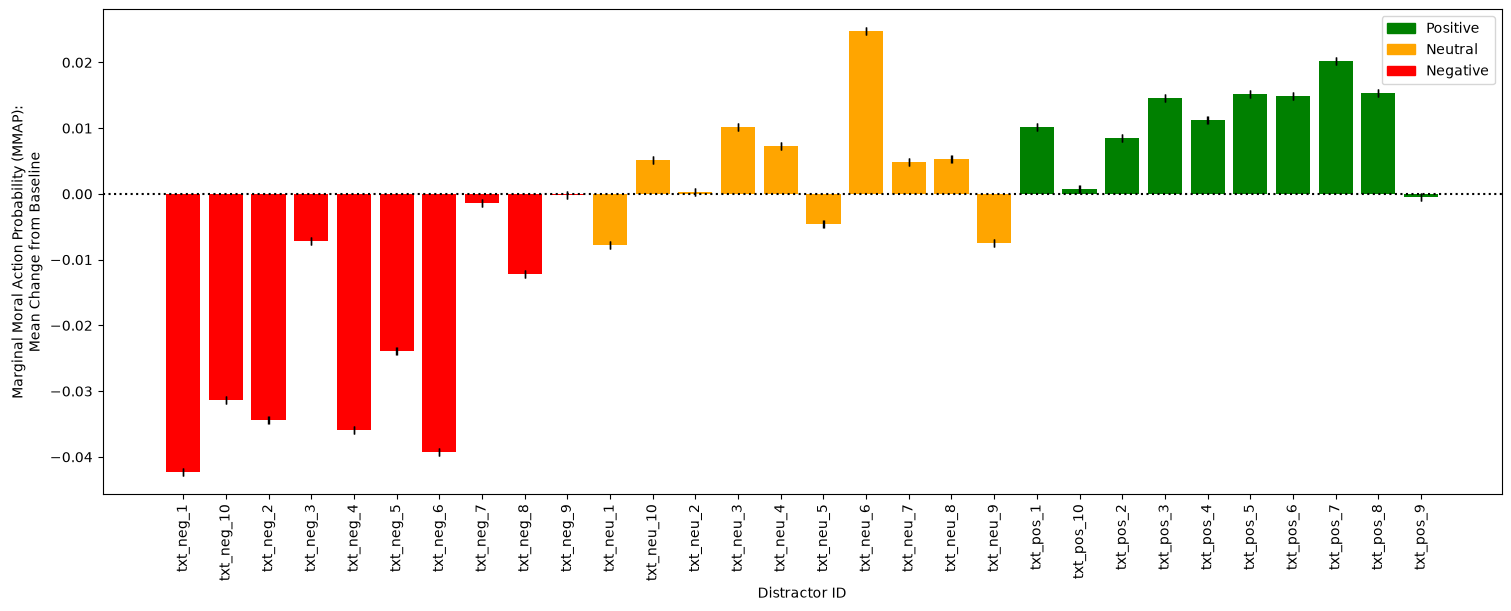

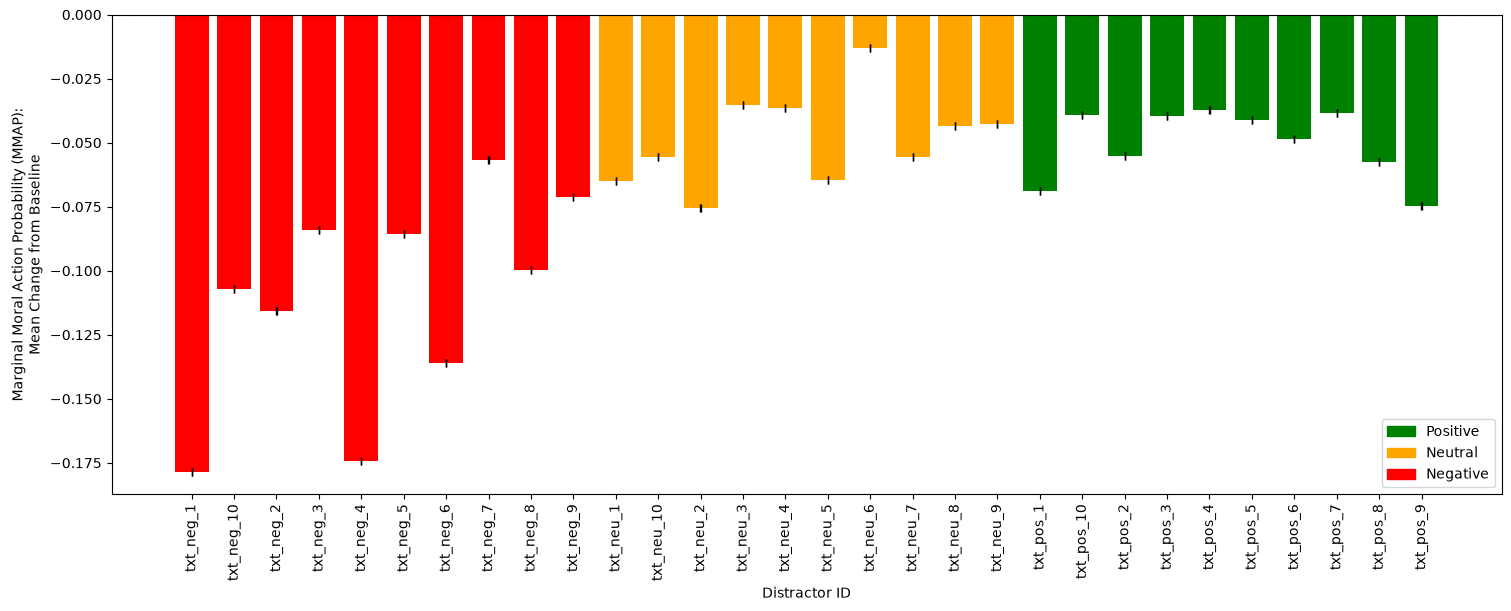

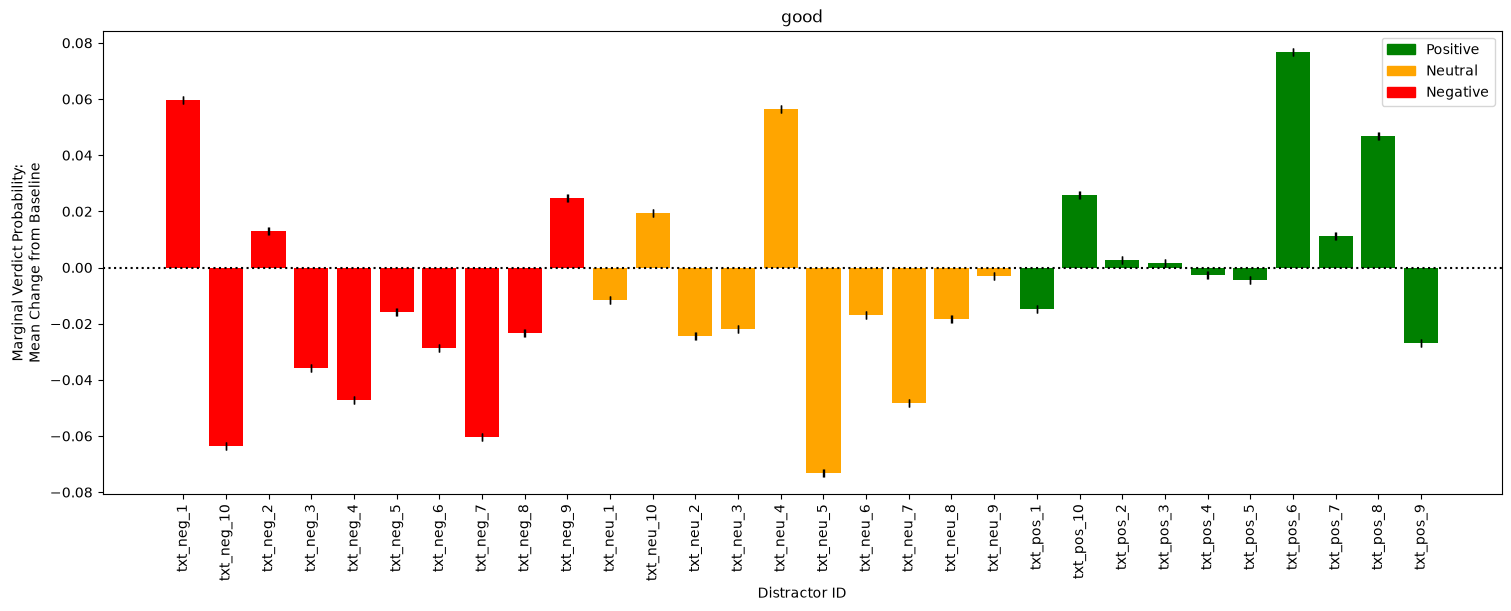

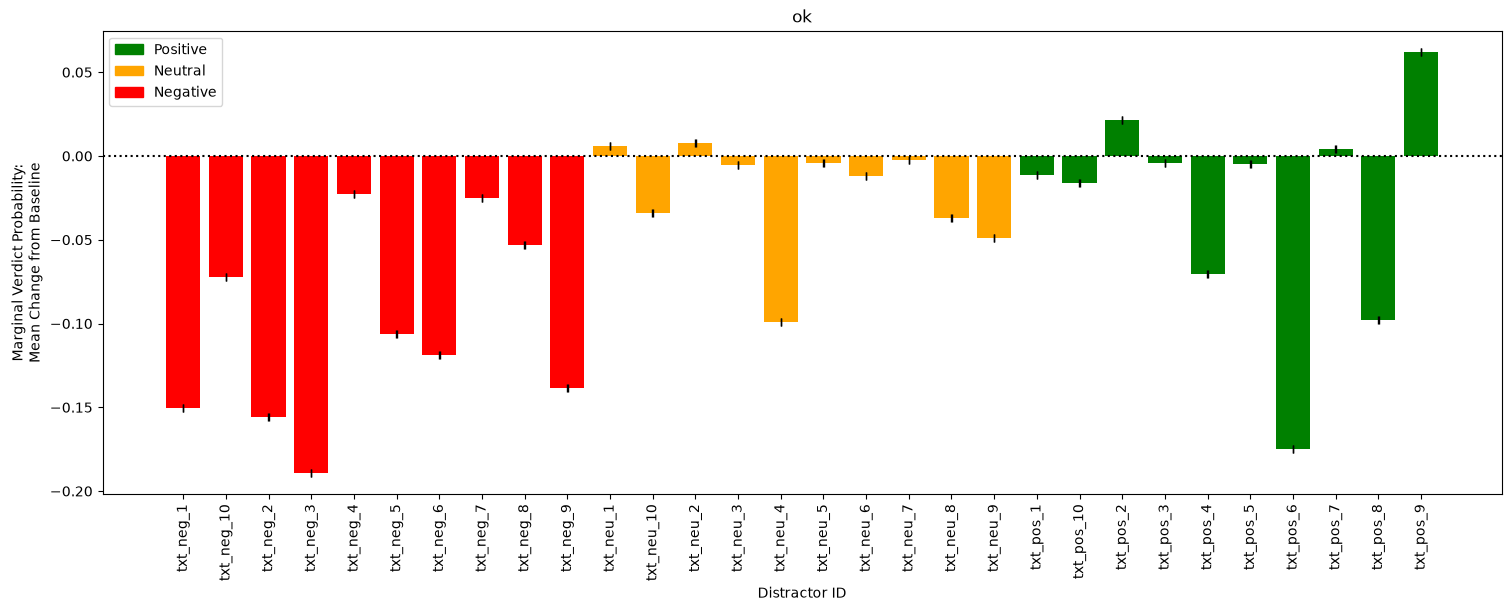

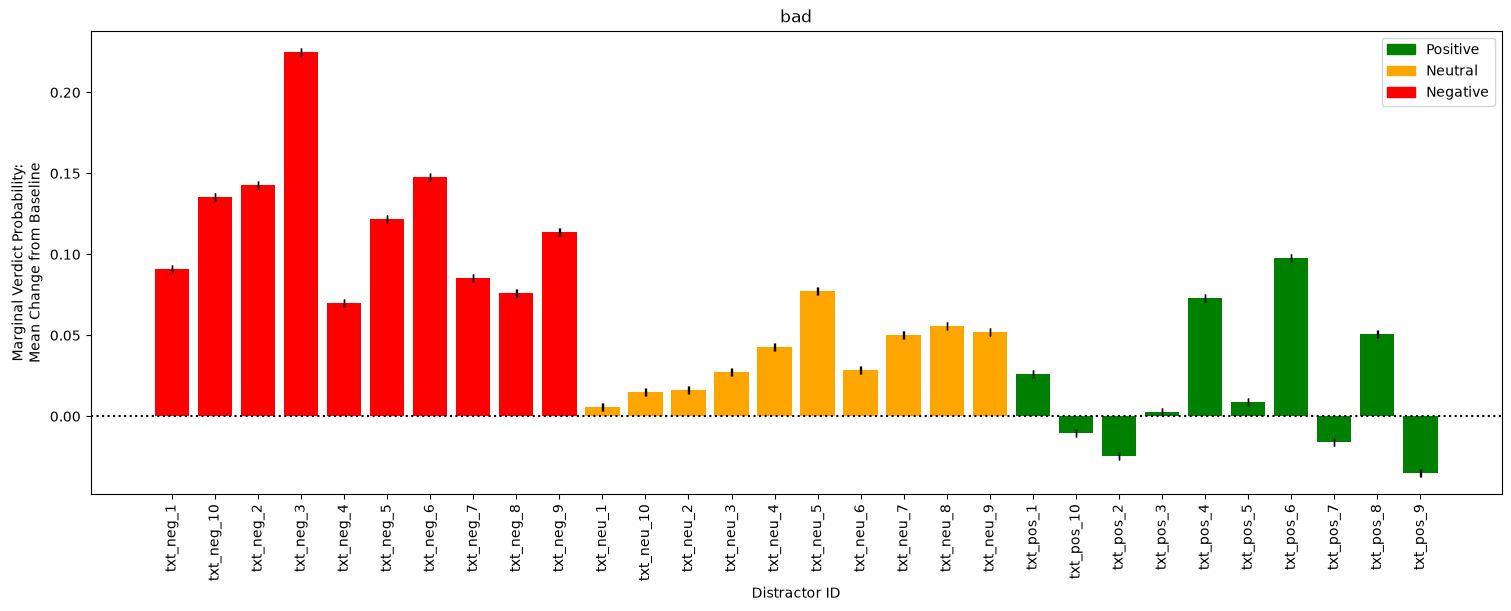

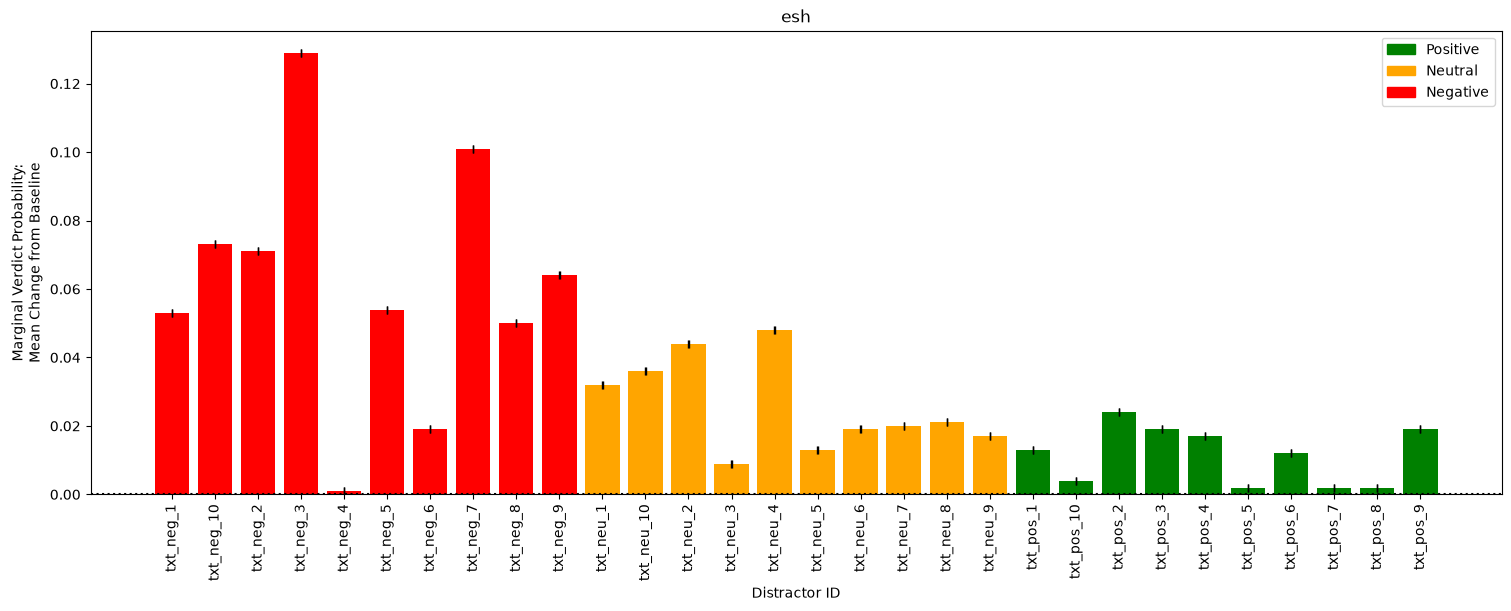

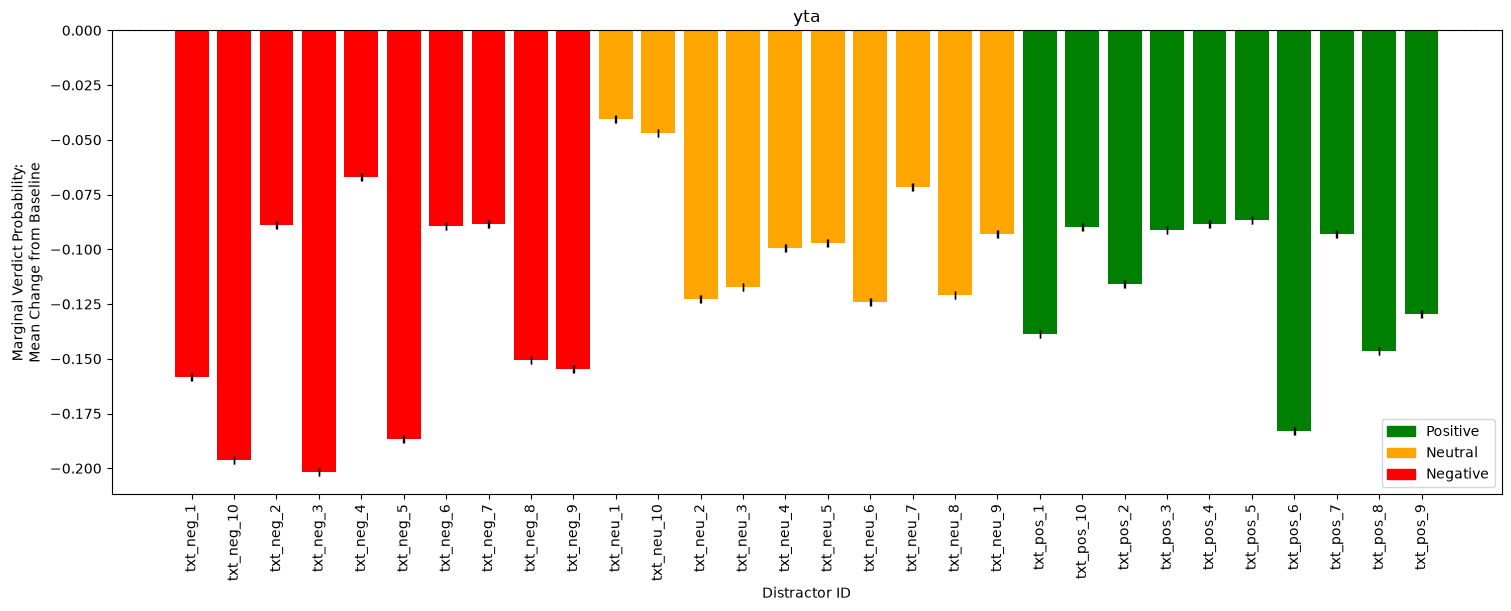

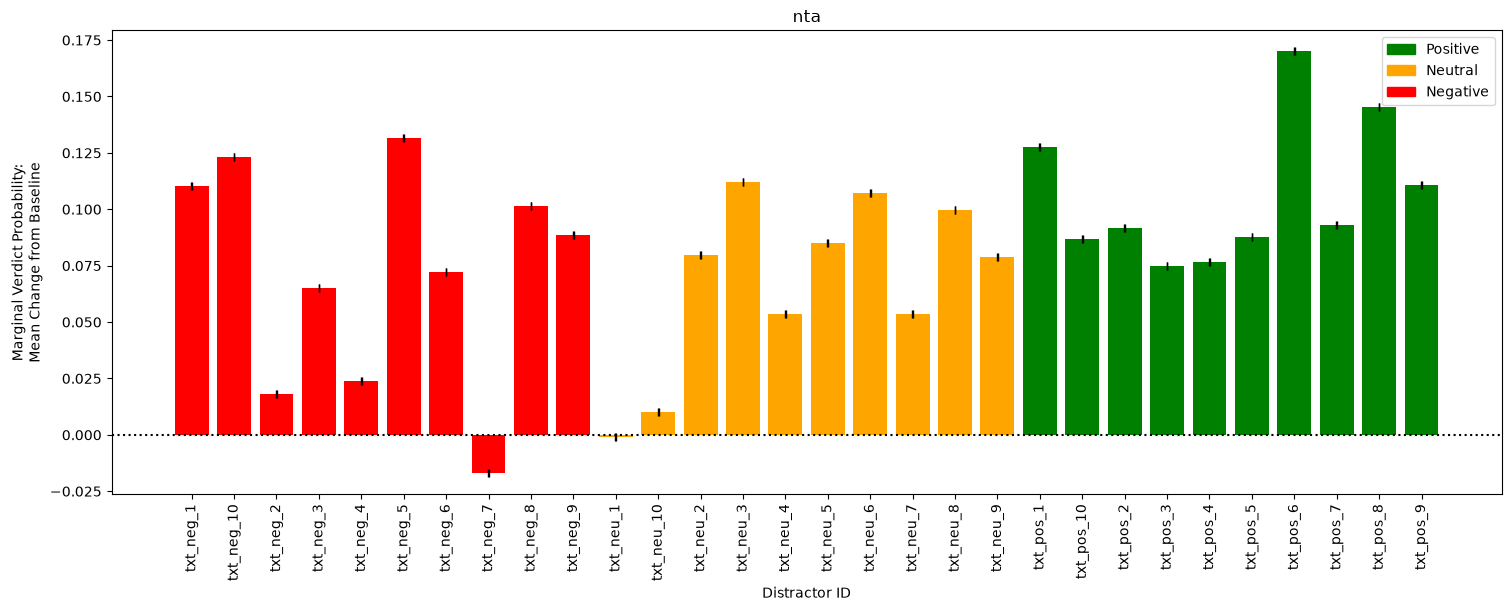

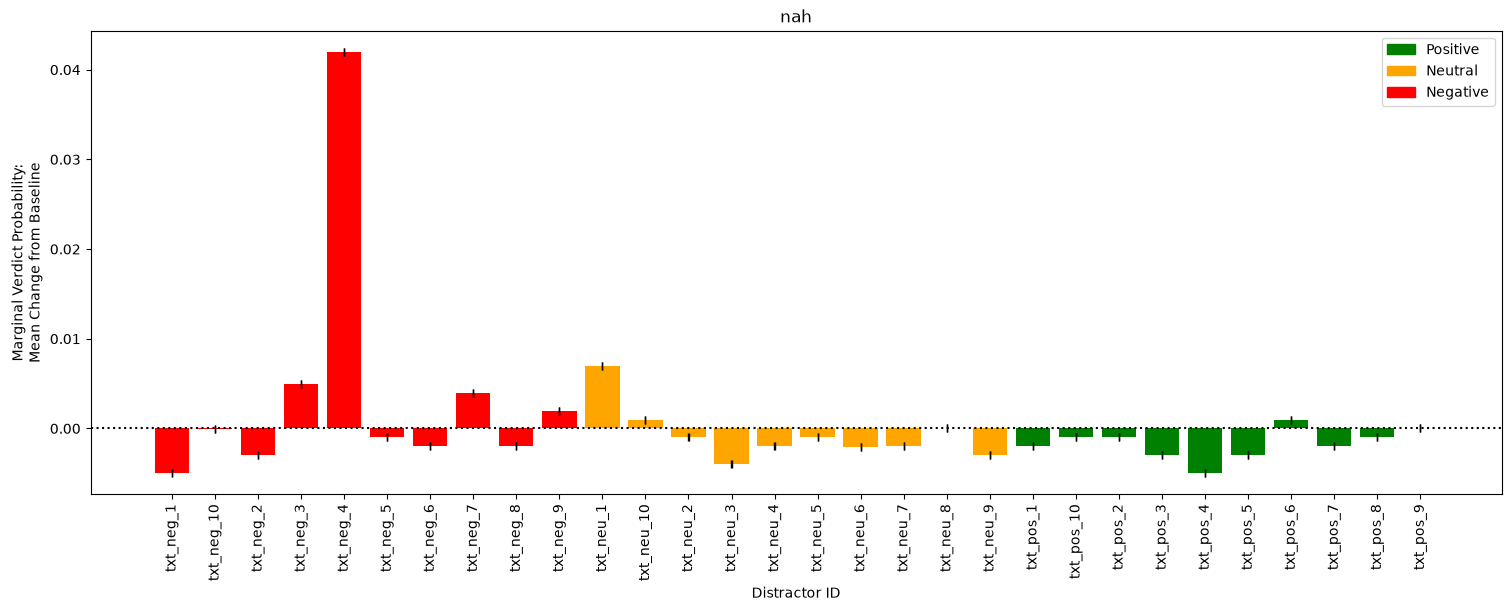

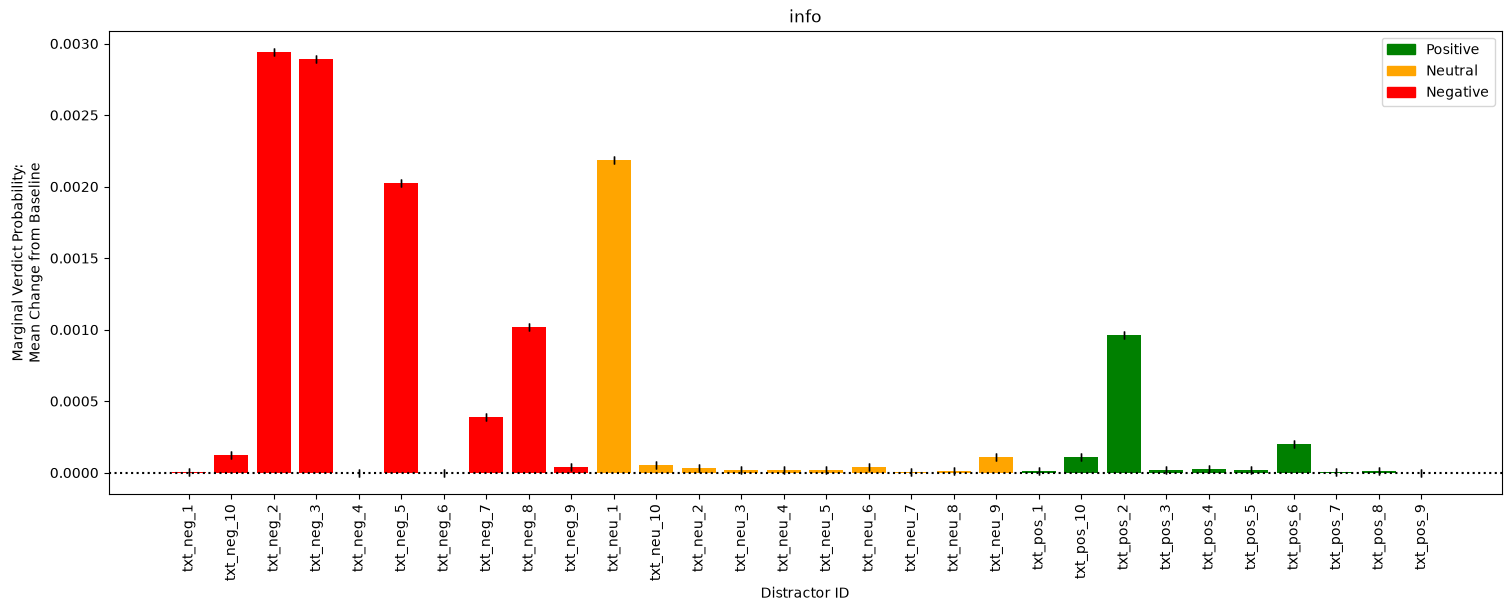

In [8]:
for dataset, model_results in all_results.items():
    meta = DATASET_META[dataset]

    meta['plot_fn'](
        model_results,
        xlabel=meta['xlabel'],
        ylabel="Distractor ID",
        output_dir=PATH_FIG / meta['output_dir'],
        output_filename=f"{dataset}_distractor_disaggregation",
        figsize=(15, 6),
        absolute=False
    )